1) Importation des librairies et chargement des fichiers

In [1]:
#Importation de la librairie Pandas
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Afficher toutes les colonnes d'un dataframe
pd.set_option('display.max_columns', None)

In [3]:
#Installe le module pyxlsb => pcq les 2 fichier en forma .xlsb 
!pip install pyxlsb

In [4]:
#Importation du fichier:All publish.xlsb
df_publish = pd.read_excel(r"C:\Users\amoul\Desktop\All_publish_VideoGame_2022.xlsb")

In [5]:
#Importation du fichier: VideoGame_sales (rq:jai supprime la feuille de tdc)
df_sales = pd.read_excel(r"C:\Users\amoul\Desktop\VideoGame_Sales_1980-2016+(1).xlsb")

In [6]:
#Importation du fichier:Vente+de+console_2022
df_Vente_console = pd.read_excel(r"C:\Users\amoul\Desktop\Vente+de+console_2022.xlsx")

2. Analyse exploratoire des fichiers

Fichier 1: All Published Video Games =>  df_publish

In [7]:
# Aperçu
#print (df_publish.head())  

# Dimensions
print (df_publish.shape )  

# Info
print (df_publish.info())  

(440896, 67)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440896 entries, 0 to 440895
Data columns (total 67 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    440896 non-null  int64  
 1   slug                  440894 non-null  object 
 2   name                  440893 non-null  object 
 3   metacritic            4627 non-null    float64
 4   released              440896 non-null  int64  
 5   Annee                 440896 non-null  int64  
 6   tba                   440896 non-null  bool   
 7   rating                440833 non-null  float64
 8   rating_top            440833 non-null  float64
 9   playtime              440833 non-null  float64
 10  achievements_count    440833 non-null  float64
 11  ratings_count         440833 non-null  float64
 12  suggestions_count     440833 non-null  float64
 13  game_series_count     440833 non-null  float64
 14  reviews_count         440833 non-null  

In [8]:
#Vérifier si il y a des lignes en doublon dans la colonne id
doublons = df_publish[df_publish['id'].duplicated(keep=False)]
print(doublons)
# => Aucun doublon n’a été détecté dans la colonne id.

Empty DataFrame
Columns: [id, slug, name, metacritic, released, Annee, tba, rating, rating_top, playtime, achievements_count, ratings_count, suggestions_count, game_series_count, reviews_count, developers, genres, publishers, esrb_rating, added_status_yet, added_status_owned, added_status_beaten, added_status_toplay, added_status_dropped, added_status_playing, platforms, PC, macOS, iOS, Web, Linux, Xbox One, Android, PS Vita, PlayStation 4, Nintendo Switch, PlayStation 2, Wii U, PlayStation 3, Xbox 36, GameCube, Wii, Xbox, Genesis, Neo Geo, Nintendo 3DS, PlayStation, PSP, Nintendo DS, Game Boy Advance, Game Boy Color, Game Boy, Nintendo DSi, SNES, SEGA Master System, Nintendo 64, Classic Macintosh, Apple II, NES, Dreamcast, PlayStation 5, Xbox Series S/X, Commodore / Amiga, Atari 26, Atari ST, Atari 78, SEGA Saturn]
Index: []


In [9]:
# Afficher les lignes en doublon dans la colonne name
df_publish['name'][df_publish['name'].duplicated()]
# il y a des doublons dans la colonne Name, mais avec des différences de plateforme et de date de réalisation.

20626      NaN
68839        1
72367     0x1d
104178      11
111000       3
157176    0x1d
177809       0
180833       0
183210       0
248252    0x1d
254798    0x1d
261285      50
265440     300
270036       3
283021    0x1d
288439    0x1d
321568       1
342304      10
345068     NaN
351863      10
396601    0x1d
421410       0
435068       2
Name: name, dtype: object

In [10]:
# Afficher les années
print(df_publish['Annee'].unique())

[2015 2016 2017 2014 2018 2010 2013 2000 2005 2007 2009 2012 2020 2019
 2003 2001 2008 2004 2011 2006 2002]


Fichier2: Ventes de jeux vidéo (VideoGame_Sale) => df_sales

In [11]:
# Aperçu
#print (df_sales.head())  

# Dimensions                            
print (df_sales.shape )         

# Info
print (df_sales.info())  

(16545, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16545 entries, 0 to 16544
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16545 non-null  int64  
 1   Name          16545 non-null  object 
 2   Platform      16545 non-null  object 
 3   Year          16274 non-null  float64
 4   Genre         16545 non-null  object 
 5   Publisher     16487 non-null  object 
 6   Constructeur  16545 non-null  object 
 7   Portable      16545 non-null  object 
 8   NA_Sales      16545 non-null  float64
 9   EU_Sales      16545 non-null  float64
 10  JP_Sales      16545 non-null  float64
 11  Other_Sales   16545 non-null  float64
 12  Global_Sales  16545 non-null  float64
dtypes: float64(6), int64(1), object(6)
memory usage: 1.6+ MB
None


In [12]:
#Vérifier si il y a des lignes en doublon dans la colonne name
print(df_sales['Name'].duplicated().sum())
df_sales['Name'][df_sales['Name'].duplicated()]
# => Il y a des doublons, mais la plateforme, les années de sortie, les constructeurs et le nombre de ventes sont différents

5085


23                                     Grand Theft Auto V
35                             Call of Duty: Black Ops II
36                         Call of Duty: Modern Warfare 3
38                                Call of Duty: Black Ops
42                                     Grand Theft Auto V
                               ...                       
16526                                     Sega Rally Revo
16529                            Akatsuki no Goei Trinity
16538                                Snood 2: On Vacation
16543                      Secret Files 2: Puritas Cordis
16544    SCORE International Baja 1000: The Official Game
Name: Name, Length: 5085, dtype: object

In [13]:
print(df_sales['Year'].unique())
df_sales['Year'].isna().sum()

[2006. 1985. 2008. 2009. 1996. 1989. 1984. 2005. 1999. 2007. 2010. 2004.
 2013. 1990. 1988. 2002. 2001. 2011. 1998. 2012. 2015. 2014. 1997. 1992.
 1993. 1994. 1982. 2003. 2000. 1986.   nan 1995. 2016. 1991. 1980. 1987.
 1981. 1983. 2020. 2017.]


np.int64(271)

Fichier 3 : Ventes de consoles => df_Vente_console

In [14]:
# Aperçu
#print (df_Vente_console.head())  

# Dimensions
print (df_Vente_console.shape )  

# Info
print (df_Vente_console.info()) 

(20, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Console             20 non-null     object 
 1   Constructeur        20 non-null     object 
 2   Date de Sortie      20 non-null     int64  
 3   Vente (en million)  20 non-null     float64
dtypes: float64(1), int64(1), object(2)
memory usage: 772.0+ bytes
None


In [15]:
#Vérifier si il y a des lignes en doublon dans la colonne Console
df_Vente_console['Console'][df_Vente_console['Console'].duplicated()]

Series([], Name: Console, dtype: object)

Analyse du marché du jeu vidéo


1) Analyse du fichier df_sales : Ventes de jeux vidéo (1980–2016)

In [16]:
# Top 10 Jeux les Plus Vendus (1980–2016)
df_sales["Year"] = df_sales["Year"].astype("Int64")
df_sales.head(10)

,Rank,Name,Platform,Year,Genre,Publisher,Constructeur,Portable,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006,Sports,Nintendo,Nintendo,Non,41.4900,27.8592,3.6569,8.2908,81.2969
1,2,Super Mario Bros.,NES,1985,Platform,Nintendo,Nintendo,Non,29.9524,3.4726,6.6738,0.8085,40.9073
2,3,Mario Kart Wii,Wii,2008,Racing,Nintendo,Nintendo,Non,15.2160,12.4936,3.7900,3.3762,34.8758
3,4,Wii Sports Resort,Wii,2009,Sports,Nintendo,Nintendo,Non,15.7500,11.0100,3.1816,3.0784,33.0200
4,5,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,Nintendo,Oui,11.2700,9.0678,9.8112,0.9900,31.1390
5,6,Tetris,GB,1989,Puzzle,Nintendo,Nintendo,Oui,22.9680,2.3278,4.0512,0.6032,29.9502
6,7,New Super Mario Bros.,DS,2006,Platform,Nintendo,Nintendo,Oui,11.1524,8.9531,6.6950,3.0160,29.8165
7,8,Wii Play,Wii,2006,Misc,Nintendo,Nintendo,Non,14.5912,9.1080,3.0472,2.9640,29.7104
8,9,New Super Mario Bros. Wii,Wii,2009,Platform,Nintendo,Nintendo,Non,14.1523,7.4130,4.7000,2.3730,28.6383
9,10,Duck Hunt,NES,1984,Shooter,Nintendo,Nintendo,Non,27.1993,0.6426,0.2856,0.4747,28.6022


Year
1980     11.4972
1981     35.6045
1982     28.9370
1983     16.8865
1984     50.8253
1985     54.6209
1986     37.0511
1987     21.6642
1988     47.2858
1989     73.3559
1990     49.8487
1991     32.4535
1992     75.7692
1993     44.3206
1994     77.8755
1995     88.3286
1996    199.4972
1997    202.2425
1998    258.4088
1999    251.5271
2000    202.2799
2001    332.7326
2002    396.3183
2003    359.2518
2004    421.4052
2005    460.7040
2006    521.6895
2007    613.9016
2008    680.4649
2009    670.2192
2010    605.2886
2011    518.2596
2012    364.4692
2013    441.6327
2014    375.1191
2015    267.6287
2016     71.1652
2017      0.0496
2020      0.2927
Name: Global_Sales, dtype: float64


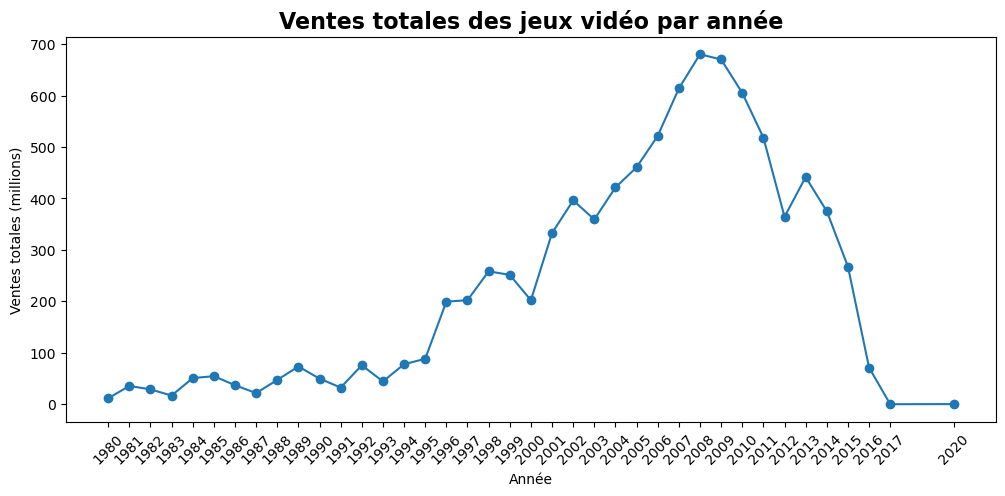

In [17]:
# Graphique des ventes mondiales par année
yearly_sales = df_sales.groupby('Year')['Global_Sales'].sum()
print(yearly_sales)
# graphique 
plt.figure(figsize=(12,5))
plt.plot(yearly_sales.index, yearly_sales.values, marker='o')
plt.title("Ventes totales des jeux vidéo par année",fontsize=16, fontweight="bold")
plt.xlabel("Année")
plt.ylabel("Ventes totales (millions)")
plt.grid(alpha=0.3)
plt.xticks(yearly_sales.index, rotation=45)  
plt.grid(False)
plt.show()

NA_Sales       4455.1341
EU_Sales       2491.1014
JP_Sales       1296.4501
Other_Sales     818.1051
dtype: float64


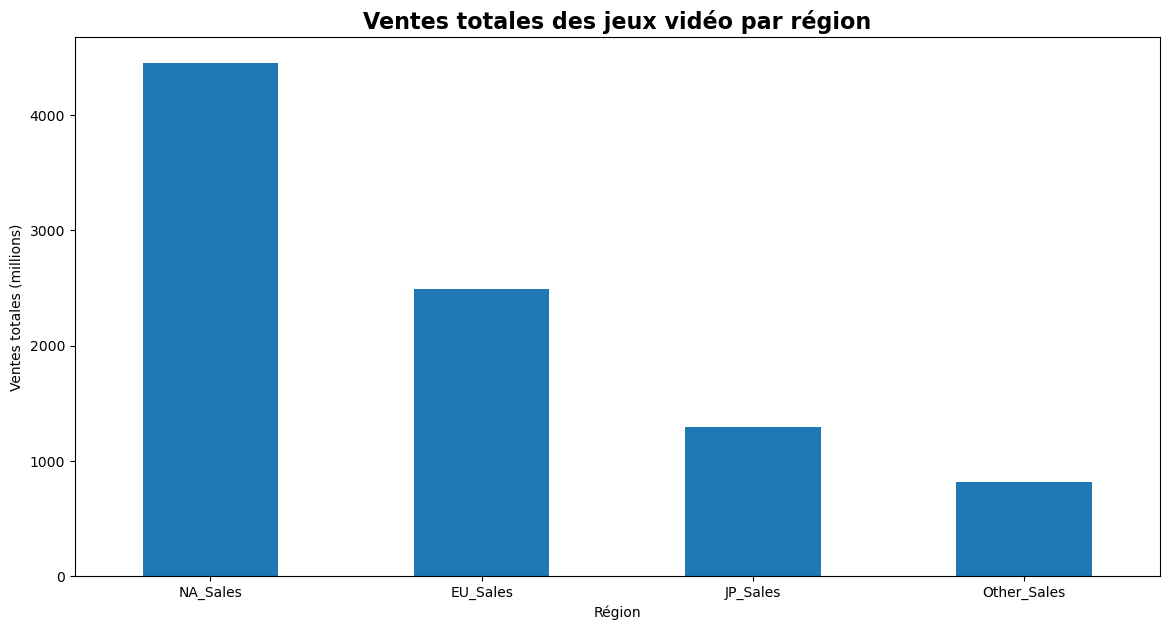

In [18]:
# Graphique des ventes par région
region_sales = df_sales[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].sum()
print(region_sales)
# graphique 
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 7))
region_sales.plot(kind='bar')
plt.title("Ventes totales des jeux vidéo par région",fontsize=16, fontweight="bold")
plt.xlabel("Région")
plt.ylabel("Ventes totales (millions)")
plt.xticks(rotation=0)
plt.grid(False)
plt.show()

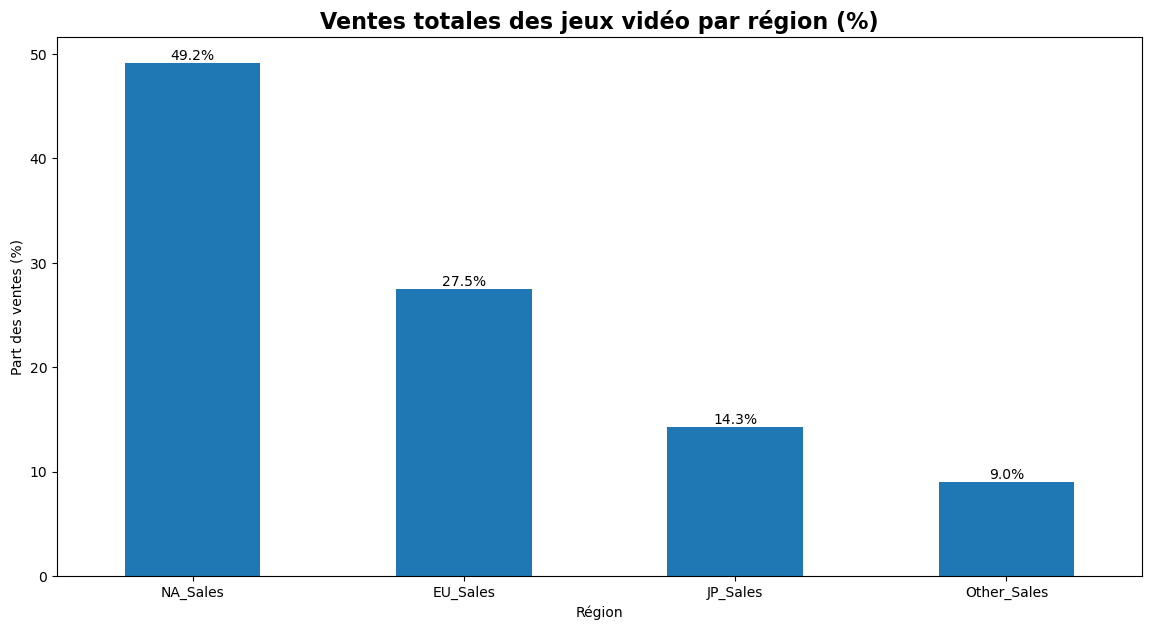

In [19]:
# Ventes totales par région (%)
import matplotlib.pyplot as plt

# Somme des ventes par région
region_sales = df_sales[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].sum()

# Conversion en %
region_sales_pct = (region_sales / region_sales.sum()) * 100

# Graphique
plt.figure(figsize=(14, 7))
ax = region_sales_pct.plot(kind='bar')

# Ajouter les %
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%",
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')

plt.title("Ventes totales des jeux vidéo par région (%)", fontsize=16, fontweight="bold")
plt.xlabel("Région")
plt.ylabel("Part des ventes (%)")
plt.xticks(rotation=0)
plt.grid(False)
plt.show()

Genre
Action          1870.4790
Sports          1335.0425
Shooter         1042.2276
Role-Playing     932.6586
Platform         831.5211
Misc             813.5179
Racing           733.8879
Fighting         449.0603
Simulation       393.6381
Puzzle           245.0191
Adventure        238.0343
Strategy         175.7043
Name: Global_Sales, dtype: float64


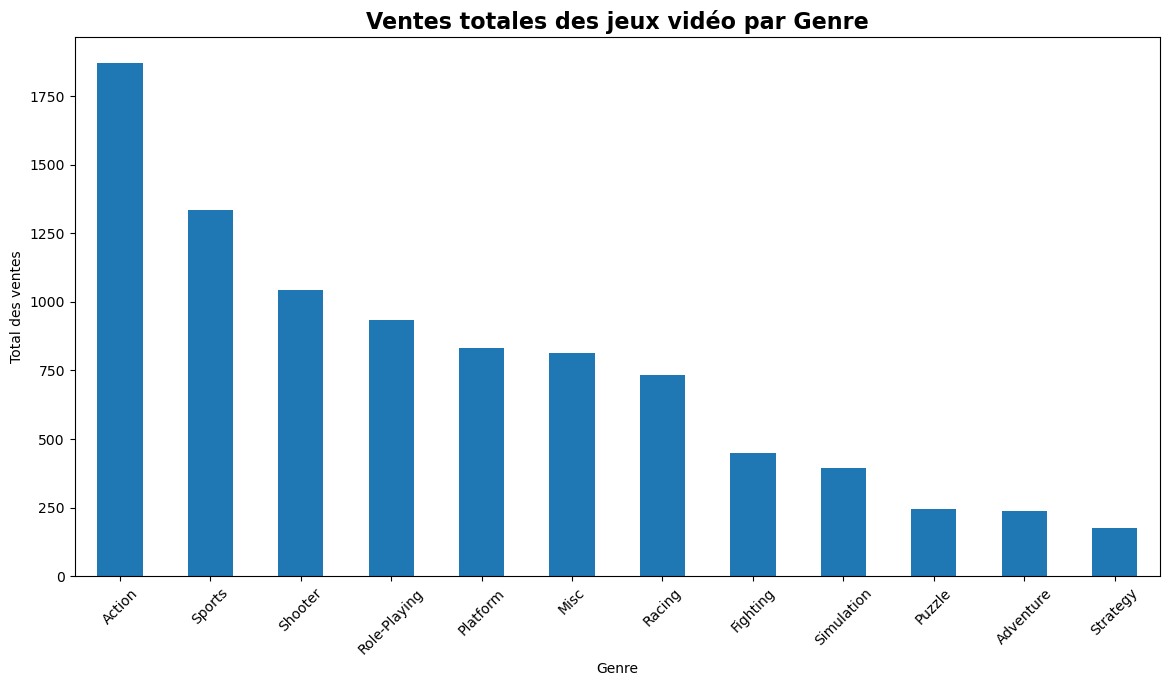

In [20]:
#Classement des genres les plus performants
Genre_Global_sales=df_sales.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False)
print(Genre_Global_sales)

# le graphique 
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 7))
Genre_Global_sales.plot(kind='bar')
plt.title("Ventes totales des jeux vidéo par Genre",fontsize=16, fontweight="bold")
plt.xlabel("Genre")
plt.ylabel("Total des ventes")
plt.xticks(rotation=45)
plt.grid(False)
plt.show()

Platform
PS2     1261.9162
X360    1016.3730
PS3     1004.7624
Wii      927.7816
DS       825.1637
PS       733.8876
GBA      319.5460
PS4      303.9189
PSP      297.9467
PC       262.3042
XB       258.6730
GB       255.4301
NES      252.6653
3DS      248.4016
N64      220.0525
SNES     200.9108
GC       199.2734
XOne     152.6086
2600      97.0371
WiiU      82.2514
PSV       61.7436
SAT       33.5676
GEN       28.3387
DC        16.0929
3DO        0.1018
GG         0.0420
Name: Global_Sales, dtype: float64


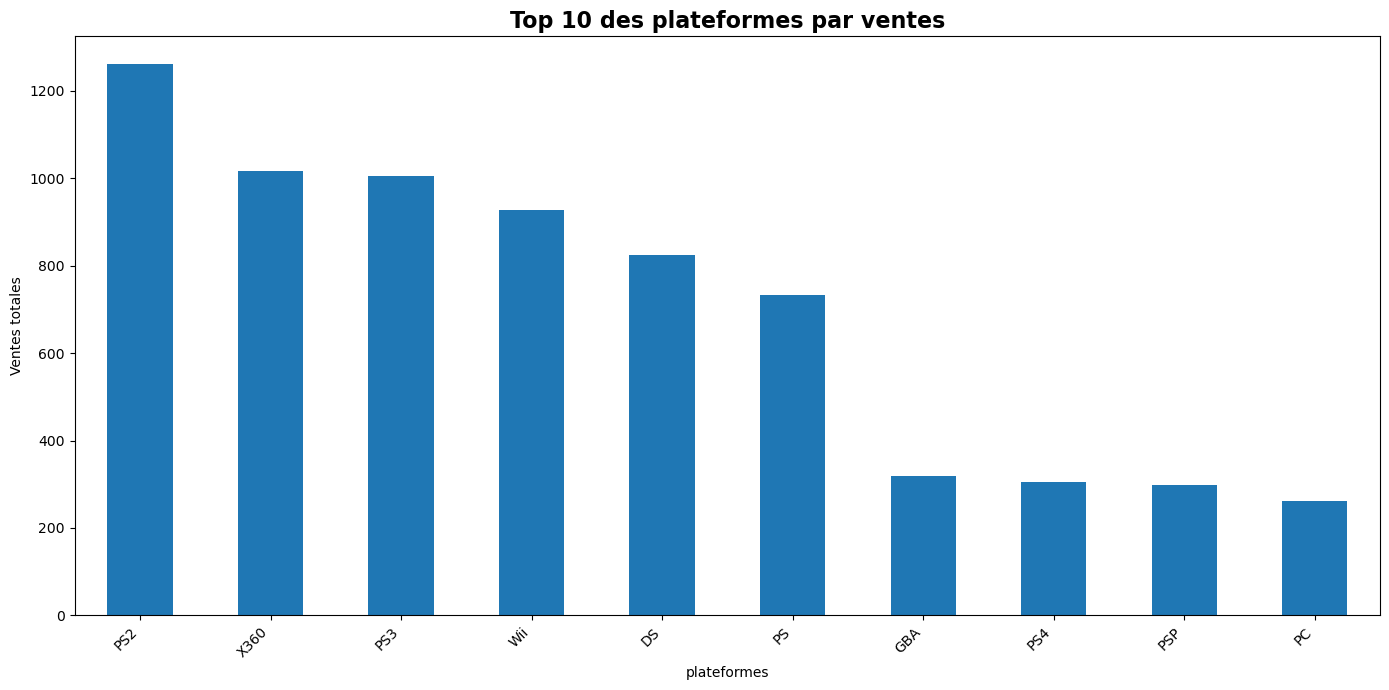

In [21]:
# Classement des plateformes les plus performantes
platform_sales = df_sales.groupby('Platform')['Global_Sales'] \
    .sum() \
    .sort_values(ascending=False)
print(platform_sales)
# graphique 
# Graphique des ventes par plateforme
import matplotlib.pyplot as plt

# Agrandir la figure
plt.figure(figsize=(14, 7))

# Création du graphique
platform_sales.head(10).plot(kind='bar')

# Titres et axes
plt.title("Top 10 des plateformes par ventes",fontsize=16, fontweight="bold")
plt.xlabel("plateformes")
plt.ylabel("Ventes totales")

# Rotation des labels
plt.xticks(rotation=45, ha='right')

# Ajustement automatique
plt.tight_layout()
plt.grid(False)
plt.show()

Publisher
Nintendo                        1790.1680
Electronic Arts                 1115.4049
Activision                       730.9071
Sony Computer Entertainment      610.6156
Take-Two Interactive             513.9410
Ubisoft                          476.7101
THQ                              342.3539
Konami Digital Entertainment     285.0538
Sega                             272.0205
Namco Bandai Games               254.7565
Name: Global_Sales, dtype: float64


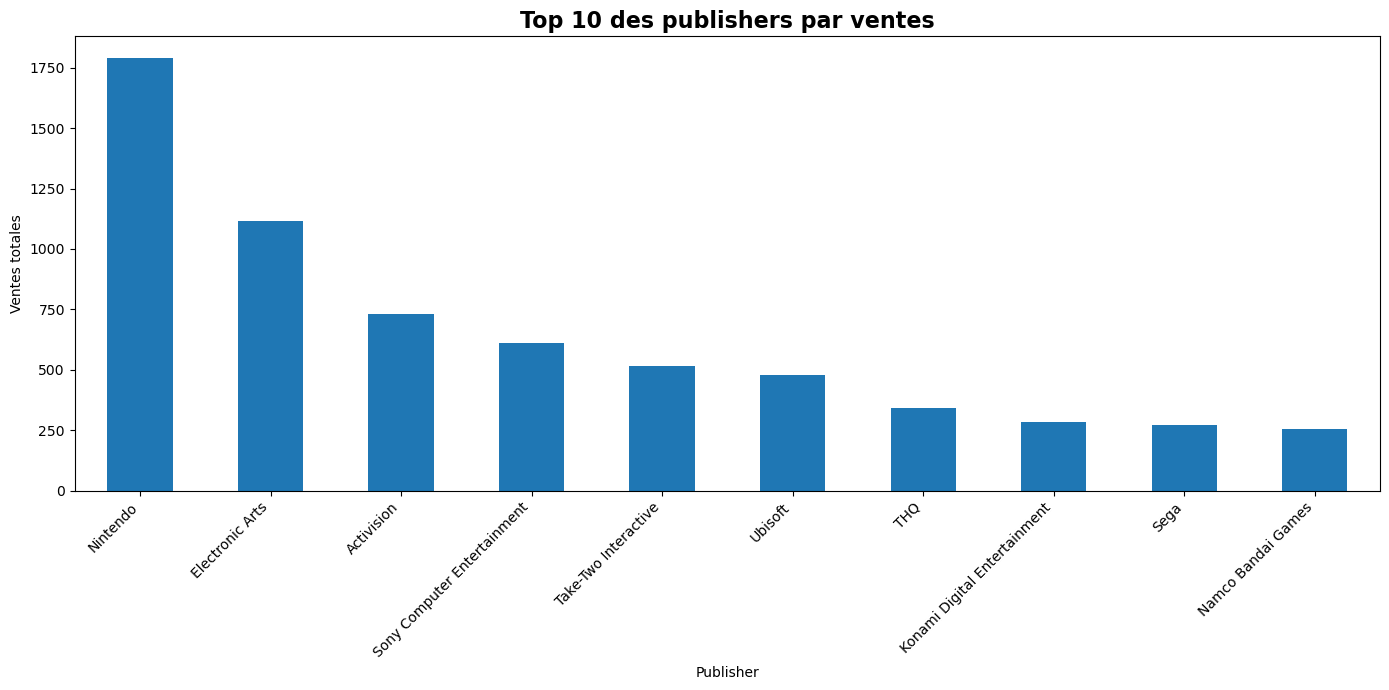

In [22]:
# Classement des Publisher les plus performantes
Publisher_sales = df_sales.groupby('Publisher')['Global_Sales'] \
    .sum() \
    .sort_values(ascending=False)
print(Publisher_sales.head(10))
# graphique 
import matplotlib.pyplot as plt

# Agrandir la figure
plt.figure(figsize=(14, 7))

# Graphique
Publisher_sales.head(10).plot(kind='bar')

# Titres et labels
plt.title("Top 10 des publishers par ventes",fontsize=16, fontweight="bold")
plt.xlabel("Publisher")
plt.ylabel("Ventes totales")

# Rotation des noms
plt.xticks(rotation=45, ha='right')

# Ajustement automatique
plt.tight_layout()
plt.grid(False)
plt.show()

 2) Analyse du df_console : Ventes de consoles 2022

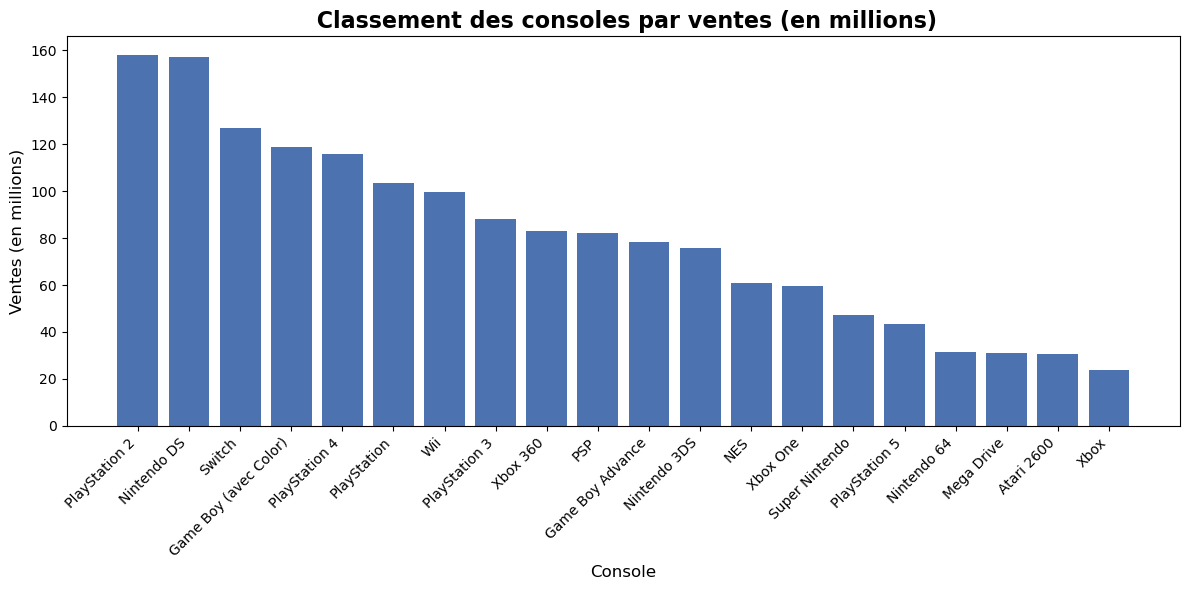

In [23]:
# Graphique des ventes des consoles (en millions)
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))  # Taille plus lisible

# Tri des consoles par ventes (optionnel mais rend le graphique plus clair)
df_sorted = df_Vente_console.sort_values(by="Vente (en million)", ascending=False)

plt.bar(df_sorted["Console"], df_sorted["Vente (en million)"], color="#4C72B0")

plt.title(" Classement des consoles par ventes (en millions)", fontsize=16, fontweight="bold")
plt.xlabel("Console", fontsize=12)
plt.ylabel("Ventes (en millions)", fontsize=12)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()  # Ajuste automatiquement les marges
plt.grid(False)
plt.show()

Constructeur
Nintendo     795.8742
Sony         590.5010
Microsoft    166.9400
Sega          31.0575
Atari         30.6000
Name: Vente (en million), dtype: float64


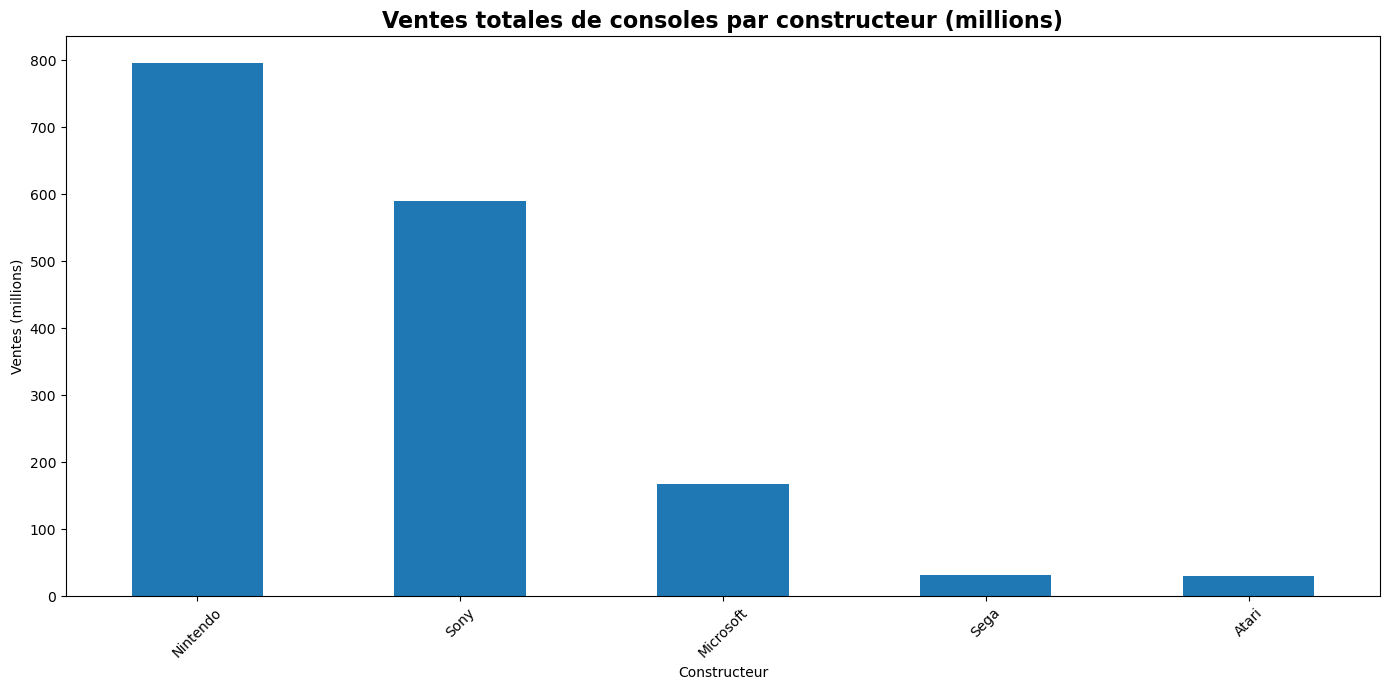

In [24]:
# Ventes totales de consoles par constructeur
import matplotlib.pyplot as plt
# Calcul des ventes par constructeur
table = df_Vente_console.groupby('Constructeur')['Vente (en million)'] \
    .sum() \
    .sort_values(ascending=False)

# Affichage du tableau
print(table)

# Graphique
plt.figure(figsize=(14, 7))

table.plot(kind='bar')

plt.title("Ventes totales de consoles par constructeur (millions)", fontsize=16, fontweight="bold")
plt.xlabel("Constructeur")
plt.ylabel("Ventes (millions)")
plt.xticks(rotation=45)
plt.grid(False)

plt.tight_layout()
plt.show()

3) Analyse du df_publish : catalogue des jeux vidéo (2000–2020), publié en 2022


Nombre de jeux sortis par an :
Annee
2000       928
2001      1060
2002       936
2003      1067
2004      1082
2005      1078
2006      1196
2007      1483
2008      1937
2009      3007
2010      3783
2011      4212
2012      5266
2013      6223
2014     15439
2015     26225
2016     41065
2017     56173
2018     71152
2019     79134
2020    118450


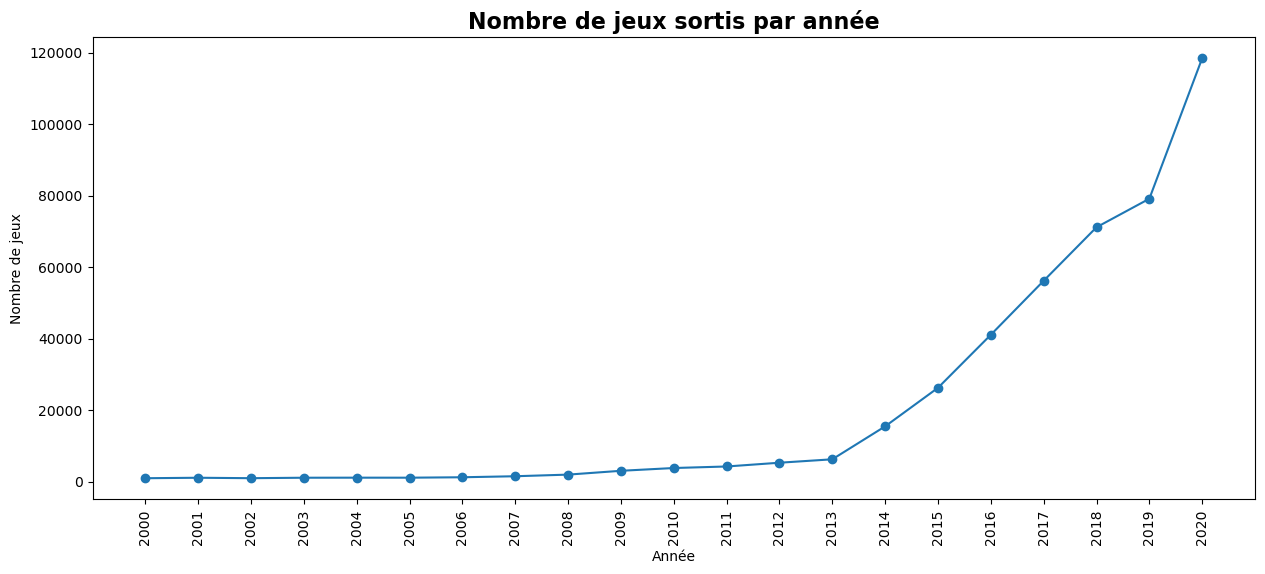

In [25]:
# 1) Nombre de jeux sortis par année (2000-2020)
yearly = df_publish["Annee"].value_counts().sort_index()
print("\nNombre de jeux sortis par an :")
print(yearly.to_string())

# Graphique en courbe
plt.figure(figsize=(15,6))
plt.plot(yearly.index, yearly.values, marker='o')

# Titres
plt.title("Nombre de jeux sortis par année",fontsize=16, fontweight="bold")
plt.xlabel("Année")
plt.ylabel("Nombre de jeux")

# Afficher toutes les années
plt.xticks(yearly.index, rotation=90)


plt.grid(False)
plt.show()

                    genre  Nombre de jeux
0                  Action           94066
1               Adventure           66687
12                 Puzzle           53499
11             Platformer           47704
16             Simulation           37592
15                Shooter           30889
18               Strategy           29701
13                    RPG           28403
9                   Indie           26943
5                  Casual           24575
2                  Arcade           19351
14                 Racing           14875
17                 Sports           13922
3             Board Games            6764
6             Educational            6409
8                Fighting            5809
7                  Family            5185
4                    Card            3217
10  Massively Multiplayer            1682


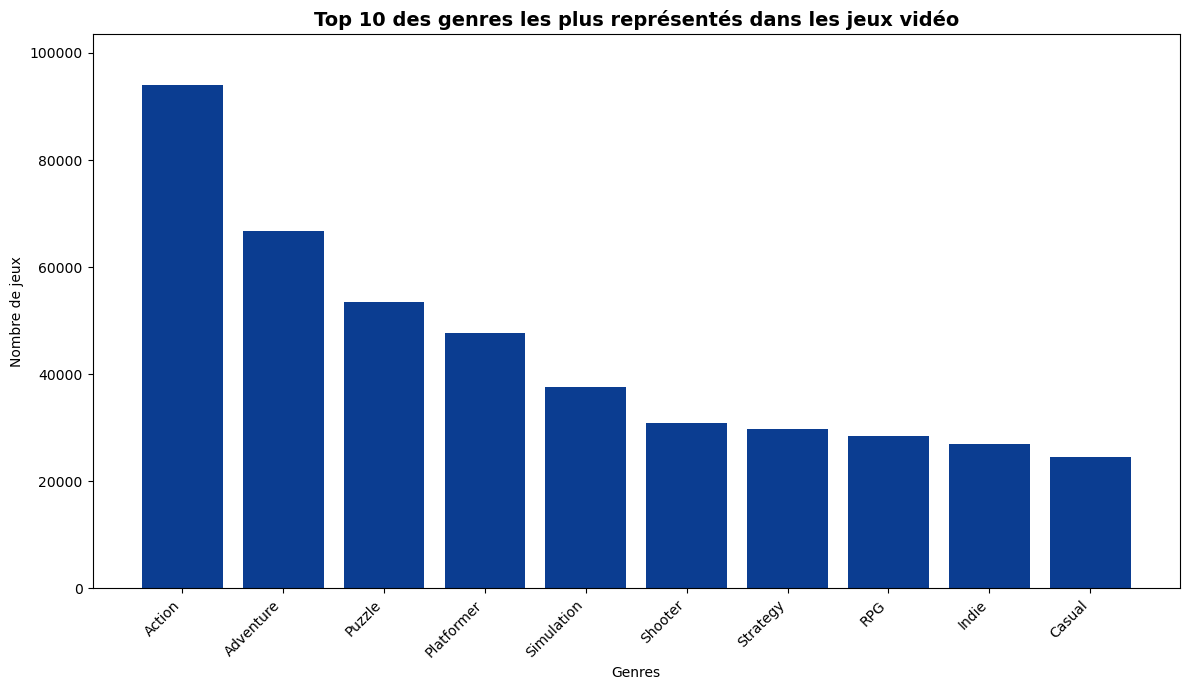

In [26]:
# 2) genres 
# Répartition des genres
import pandas as pd
import matplotlib.pyplot as plt

# 1. Split des genres + explosion en lignes 
df_exploded = df_publish.assign( genre=df_publish['genres'].str.split(r'\|\|') ).explode('genre') 
# 2. Nettoyage des espaces 
df_exploded['genre'] = df_exploded['genre'].str.strip()
# 3. Comptage du nombre de jeux uniques par genre
genre_counts = df_exploded.groupby('genre')['id'].nunique().reset_index() 
# 4. Renommage des colonnes 
genre_counts.columns = ['genre', 'Nombre de jeux']
# 5. Tri décroissant
genre_counts= genre_counts.sort_values('Nombre de jeux', ascending=False)
print(genre_counts)

# 7. Graphique
plt.figure(figsize=(12, 7))
genre_counts = genre_counts.sort_values('Nombre de jeux', ascending=False).head(10)

plt.bar(genre_counts['genre'], genre_counts['Nombre de jeux'], color="#0B3D91")

plt.title("Top 10 des genres les plus représentés dans les jeux vidéo",fontweight='bold',fontsize=14)
plt.xlabel("Genres")
plt.ylabel("Nombre de jeux")

max_val = genre_counts['Nombre de jeux'].max()
plt.ylim(0, max_val * 1.1)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

                                              genres  metacritic
1519                                 Shooter||Puzzle        95.0
976                           Adventure||RPG||Puzzle        94.0
772                       Action||Sports||Platformer        94.0
351                         Action||Casual||Fighting        92.5
334        Action||Arcade||Indie||Puzzle||Platformer        92.0
1740            Strategy||Board Games||Casual||Indie        91.0
590   Action||Shooter||Casual||Massively Multiplayer        91.0
618                 Action||Shooter||RPG||Platformer        90.0
1777    Strategy||Educational||Family||Indie||Puzzle        90.0
875                Adventure||Arcade||Casual||Family        89.0


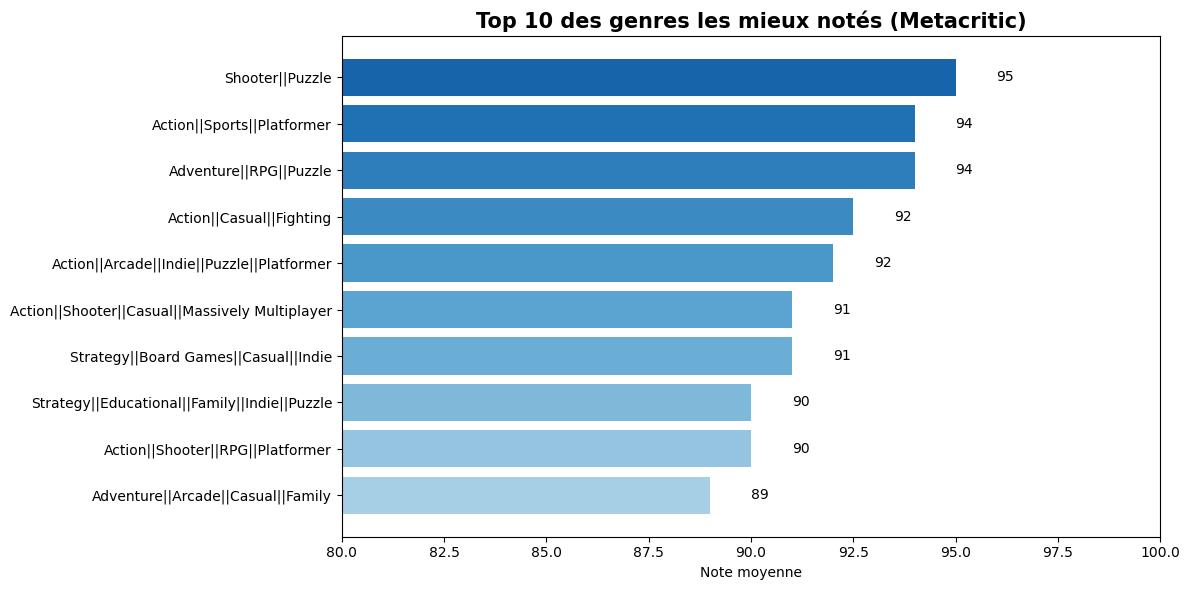

In [27]:
# Top 10 des genres les mieux notés (Metacritic)
genres_metacritic= (
    df_publish
    .groupby("genres")["metacritic"]
    .mean()
    .reset_index()
    .sort_values("metacritic", ascending=False)
)

print(genres_metacritic.head(10))

# graphique 
import matplotlib.pyplot as plt

top10 = genres_metacritic.head(10).sort_values("metacritic", ascending=True)

plt.figure(figsize=(12, 6))

# Palette douce type "Blues"
colors = plt.cm.Blues([0.35 + i*0.05 for i in range(len(top10))])

plt.barh(top10["genres"], top10["metacritic"], color=colors)

# Valeurs à droite des barres (avec espace)
for i, v in enumerate(top10["metacritic"]):
    plt.text(v + 1, i, f"{v:.0f}", va="center", fontsize=10)

# Titre + sous-titre
plt.title("Top 10 des genres les mieux notés (Metacritic)", fontsize=15, fontweight="bold")

# Style axes
plt.xlabel("Note moyenne")
plt.xlim(80, top10["metacritic"].max() + 5)

#  Enlever toute la grille
plt.grid(False)

plt.tight_layout()
plt.show()



                                                 genres  rating
1648         Simulation||Sports||Racing||Arcade||Puzzle    4.45
690   Action||Simulation||Arcade||Massively Multipla...    4.41
1249           Casual||Card||Educational||Indie||Puzzle    4.37
119   Action||Adventure||RPG||Simulation||Sports||Ra...    4.35
1304                      Massively Multiplayer||Puzzle    4.33
1013                   Adventure||RPG||Strategy||Arcade    4.30
952                                Adventure||RPG||Card    4.29
1128                Adventure||Strategy||Arcade||Puzzle    4.20
334           Action||Arcade||Indie||Puzzle||Platformer    4.18
966                      Adventure||RPG||Family||Puzzle    4.15


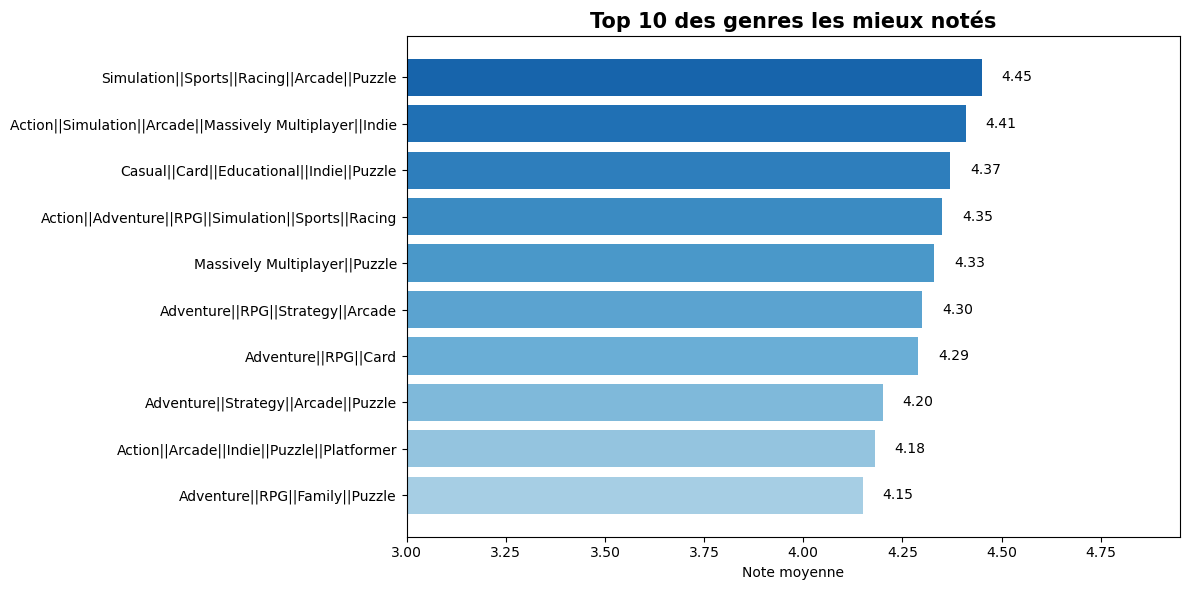

In [28]:
#Top 10 des genres les mieux notés
genres_rating= (
    df_publish
    .groupby("genres")["rating"]
    .mean()
    .reset_index()
    .sort_values("rating", ascending=False)
)

print(genres_rating.head(10))

# graphique 
# Top 10 genres par rating
top10 = genres_rating.head(10).sort_values("rating", ascending=True)

plt.figure(figsize=(12, 6))

# Palette douce type "Blues"
colors = plt.cm.Blues([0.35 + i*0.05 for i in range(len(top10))])

plt.barh(top10["genres"], top10["rating"], color=colors)

# Valeurs à droite des barres (avec espace)
for i, v in enumerate(top10["rating"]):
    plt.text(v + 0.05, i, f"{v:.2f}", va="center", fontsize=10)

# Titre + sous-titre
plt.title("Top 10 des genres les mieux notés", fontsize=15, fontweight="bold")

# Style axes
plt.xlabel("Note moyenne")
plt.xlim(3, top10["rating"].max() + 0.5)

#  Enlever toute la grille
plt.grid(False)

plt.tight_layout()
plt.show()

              platform  Nombre de jeux
23                  PC          258865
35                 Web          111506
42                 iOS           67002
43               macOS           59604
15               Linux           41578
1              Android           23084
29       PlayStation 4            5087
40            Xbox One            3798
22     Nintendo Switch            3758
28       PlayStation 3            3177
39            Xbox 360            2370
20         Nintendo DS            2118
36                 Wii            1860
24             PS Vita            1670
18        Nintendo 3DS            1478
27       PlayStation 2            1455
25                 PSP            1281
37               Wii U            1038
10    Game Boy Advance             672
38                Xbox             655
13            GameCube             598
26         PlayStation             366
8            Dreamcast             183
6    Classic Macintosh             175
11      Game Boy Color   

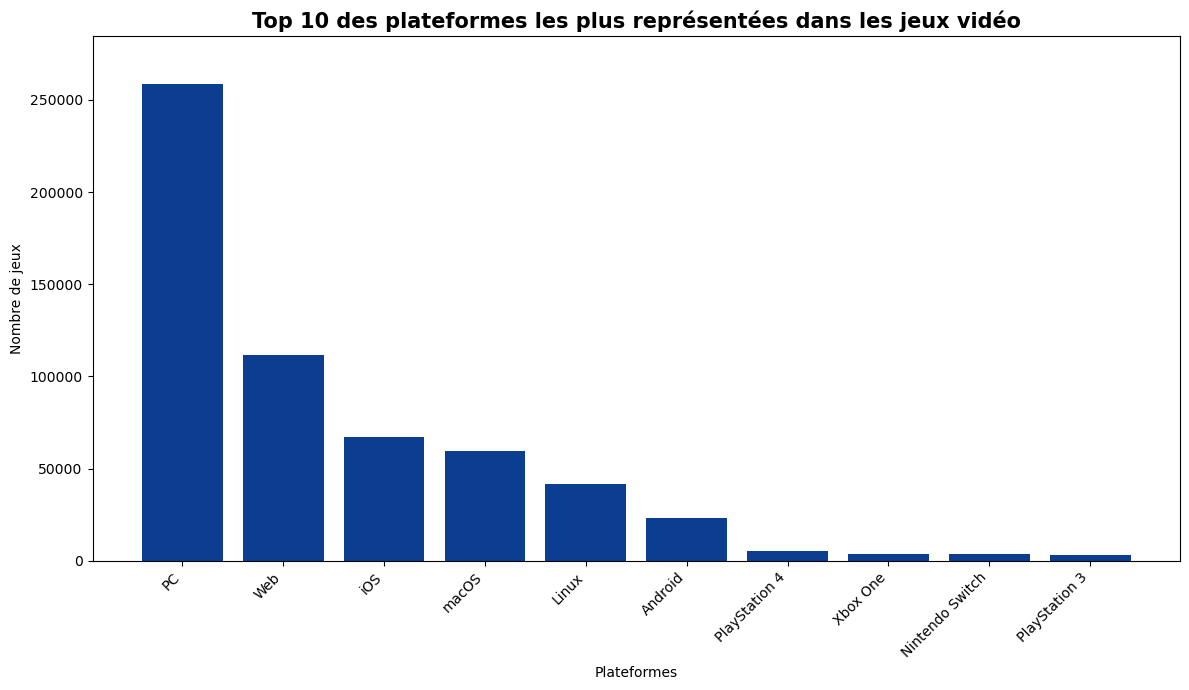

In [29]:
# 2) plateformes
# Répartition des plateformes:
# 1. Split des plateformes + explosion en lignes
df_exploded = df_publish.assign(
    platform=df_publish['platforms'].str.split(r'\|\|')
).explode('platform')

# 2. Nettoyage des espaces
df_exploded['platform'] = df_exploded['platform'].str.strip()

# 3. Comptage du nombre de jeux uniques par plateforme
platform_counts = df_exploded.groupby('platform')['id'].nunique().reset_index()

# 4. Renommage des colonnes
platform_counts.columns = ['platform', 'Nombre de jeux']

# 5. Tri décroissant
platform_counts = platform_counts.sort_values('Nombre de jeux', ascending=False)
print(platform_counts)

# 6. Graphique
plt.figure(figsize=(12, 7))

platform_counts = platform_counts.sort_values('Nombre de jeux', ascending=False).head(10)

plt.bar(platform_counts['platform'], platform_counts['Nombre de jeux'], color="#0B3D91")

plt.title("Top 10 des plateformes les plus représentées dans les jeux vidéo",fontweight='bold', fontsize=15)

plt.xlabel("Plateformes")
plt.ylabel("Nombre de jeux")

max_val = platform_counts['Nombre de jeux'].max()
plt.ylim(0, max_val * 1.1)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

                                              platforms  metacritic
1498  PC||Xbox Series S/X||PlayStation 5||PlayStatio...        97.0
2572                    Xbox One||Nintendo 64||Xbox 360        97.0
857                         Nintendo Switch||Wii||Wii U        97.0
1805  PS Vita||Xbox||Xbox 360||PlayStation 2||PlaySt...        96.0
2614  Xbox One||PC||PlayStation 4||PlayStation 3||ma...        96.0
17            Android||Linux||Xbox||macOS||PC||Xbox 360        96.0
1477          PC||Xbox One||PlayStation 4||macOS||Linux        95.0
197                                  Android||macOS||PC        95.0
2444                                         Wii||Wii U        95.0
2649  Xbox One||PlayStation 3||PC||Xbox 360||Linux||...        95.0


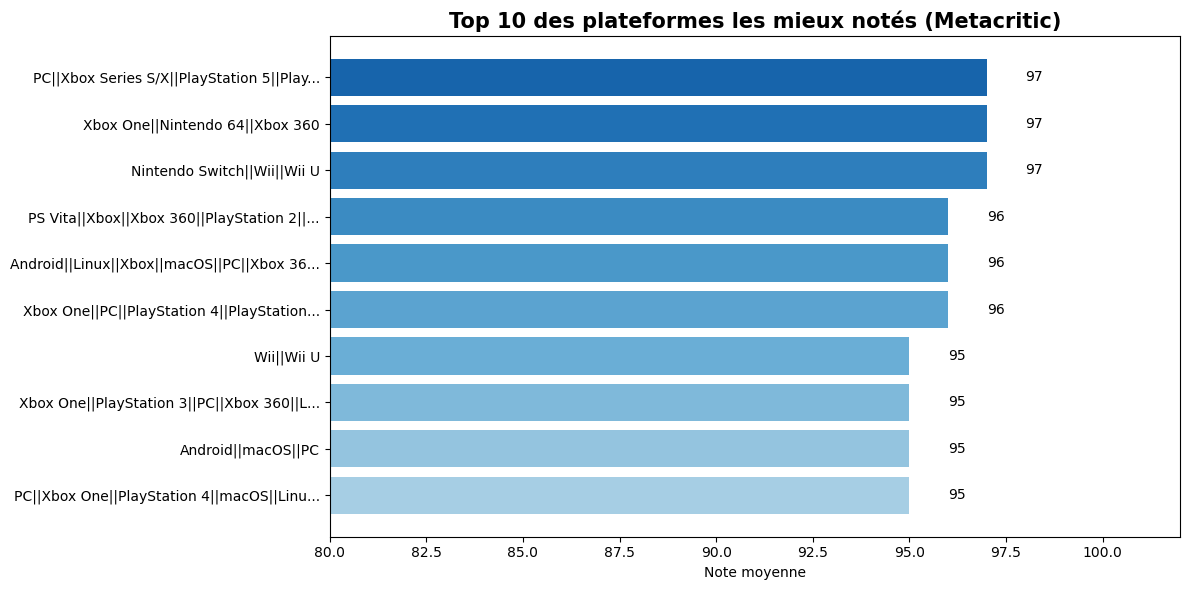

In [30]:
# Top 10 des plateformes les mieux notés (Metacritic)
platforms_metacritic = (
    df_publish
    .groupby("platforms")["metacritic"]
    .mean()
    .reset_index()
    .sort_values("metacritic", ascending=False)
)

print(platforms_metacritic.head(10))

# graphique 
import matplotlib.pyplot as plt

top10 = platforms_metacritic.head(10).sort_values("metacritic", ascending=True)

# Raccourcir les noms trop longs (40 caractères max)
top10["platforms_short"] = top10["platforms"].apply(
    lambda x: x[:40] + "..." if len(x) > 40 else x
)

plt.figure(figsize=(12, 6))

colors = plt.cm.Blues([0.35 + i*0.05 for i in range(len(top10))])

plt.barh(top10["platforms_short"], top10["metacritic"], color=colors)

# Valeurs à droite des barres 
for i, v in enumerate(top10["metacritic"]):
    plt.text(v + 1, i, f"{v:.0f}", va="center", fontsize=10)

# Titre 
plt.title("Top 10 des plateformes les mieux notés (Metacritic)", fontsize=15, fontweight="bold")

# Style axes
plt.xlabel("Note moyenne")
plt.xlim(80, top10["metacritic"].max() + 5)

# Enlever toute la grille
plt.grid(False)

plt.tight_layout()
plt.show()

                                              platforms  rating
750   Nintendo Switch||Linux||macOS||PC||Xbox One||W...    4.78
2989                            iOS||Linux||PC||Android    4.75
2237  PlayStation 5||Xbox Series S/X||Xbox One||PC||...    4.73
2126  PlayStation 4||PC||iOS||Linux||macOS||Xbox One...    4.67
2708                                     Xbox One||Xbox    4.67
2649  Xbox One||PlayStation 3||PC||Xbox 360||Linux||...    4.61
3381  macOS||PC||Linux||Wii U||Nintendo 3DS||Nintend...    4.61
2322                      Wii U||NES||Wii||Nintendo 3DS    4.60
1123  PC||Nintendo 3DS||macOS||Linux||Nintendo Switc...    4.59
3493  macOS||Wii U||Xbox One||Nintendo 3DS||PC||Play...    4.55


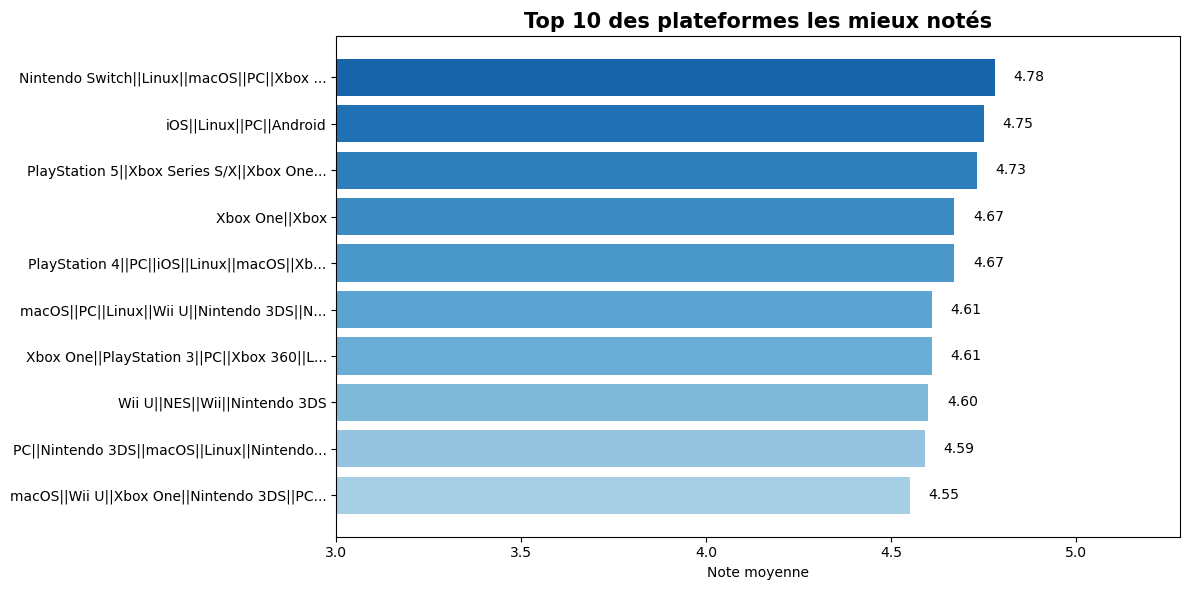

In [31]:
#Top 10 des plateformes les mieux notés
platforms_rating= (
    df_publish
    .groupby("platforms")["rating"]
    .mean()
    .reset_index()
    .sort_values("rating", ascending=False)
)

print(platforms_rating.head(10))

# graphique 
# Top 10 plateformes par rating
top10 = platforms_rating.head(10).sort_values("rating", ascending=True)

# Raccourcir les noms trop longs
top10["platforms_short"] = top10["platforms"].apply(
    lambda x: x[:40] + "..." if len(x) > 40 else x
)

plt.figure(figsize=(12, 6))
colors = plt.cm.Blues([0.35 + i*0.05 for i in range(len(top10))])

plt.barh(top10["platforms_short"], top10["rating"], color=colors)

# Valeurs à droite des barres
for i, v in enumerate(top10["rating"]):
    plt.text(v + 0.05, i, f"{v:.2f}", va="center", fontsize=10)

# Titre 
plt.title("Top 10 des plateformes les mieux notés", fontsize=15, fontweight="bold")

plt.xlabel("Note moyenne")
plt.xlim(3, top10["rating"].max() + 0.5)

# Enlever toute la grille
plt.grid(False)

plt.tight_layout()
plt.show()

      esrb_rating  playtime
0            Teen    7718.0
1          Mature    6149.0
2    Everyone 10+    5132.0
3        Everyone    4354.0
4     Adults Only     789.0
5  Rating Pending      41.0


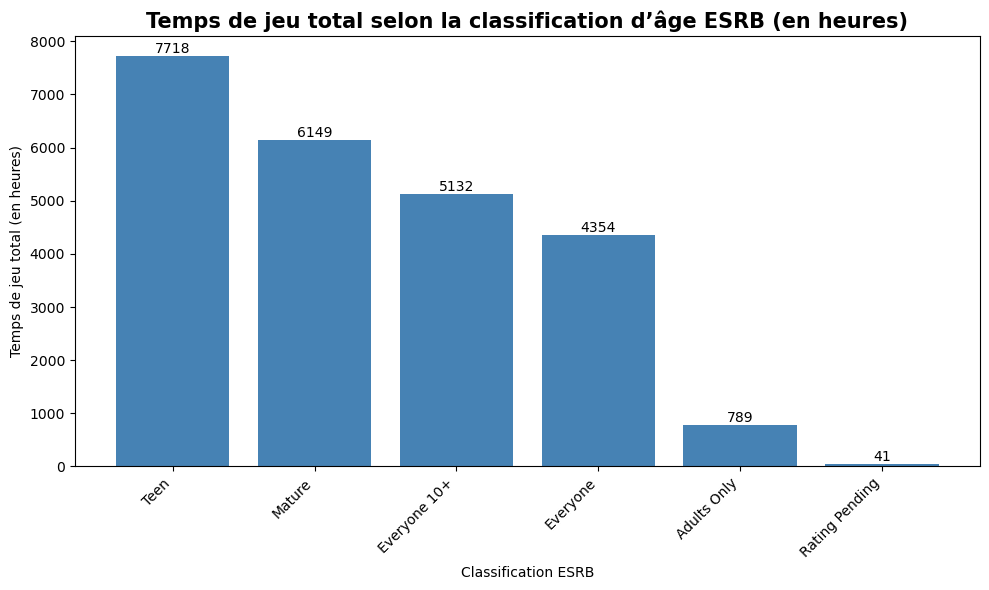

In [32]:
# 3) Playtime total par tranche d’âge ESRB 
playtime_total_by_genre_esrb = (
    df_publish[df_publish["playtime"] > 0]
    .groupby(["esrb_rating"])["playtime"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

print(playtime_total_by_genre_esrb)

# graphique 
import matplotlib.pyplot as plt

data = playtime_total_by_genre_esrb.sort_values("playtime", ascending=False)

plt.figure(figsize=(10, 6))

bars=plt.bar(data["esrb_rating"], data["playtime"], color="steelblue")

plt.title("Temps de jeu total selon la classification d’âge ESRB (en heures)" ,fontsize=15, fontweight="bold")
plt.xlabel("Classification ESRB")
plt.ylabel("Temps de jeu total (en heures)")
# ajout des valeurs
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,f'{int(height):}',ha='center', va='bottom')

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.grid(False)
plt.show()